# Model Analysis — Logistic Regression

This notebook develops and compares logistic regression models to predict customer response to a monthly food basket subscription campaign for a retail food company. Building on the EDA, which identified behavioural variables, particularly past campaign acceptance and recency, as the strongest predictors of response, the modelling strategy follows a structured diagnostic logic:

1. A **Full Model** (L1-regularised) trained on all engineered features to identify which predictors survive penalisation.
2. A **Behavioural Model** focusing on engagement and purchase history.
3. A **Demographic Model** focusing on customer profile and household composition.

Comparing these three models allows us to assess whether campaign response is better explained by *who the customer is* or *how the customer behaves*, and to select the most actionable model for deployment.

## 0. Setup & Data Loading

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay, precision_recall_curve
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

import warnings
warnings.filterwarnings('ignore')


In [26]:
# Data loading
df = pd.read_csv('../data/marketing_campaign_clean.csv')

# Data overview
print(f"Dataset shape: {df.shape}")
print(f"\nClass balance:")
print(df['Response'].value_counts(normalize=True).round(3))
df.columns

Dataset shape: (2236, 30)

Class balance:
Response
0    0.851
1    0.149
Name: proportion, dtype: float64


Index(['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Income_missing', 'Customer_Tenure', 'Age',
       'Total_Spending', 'Total_Purchases', 'Total_Accepted_Campaigns',
       'Response'],
      dtype='object')

## 1. Feature Selection

The clean dataset already contains the engineered features created in the EDA notebook
(`Total_Spending`, `Total_Purchases`, `Total_Accepted_Campaigns`, `Customer_Tenure`, `Age`).

The original columns (individual spend categories, individual campaign dummies) are
dropped here, as they have been summarised into the aggregated features. `Income_missing` and
`Complain` are also excluded-

Three non-overlapping feature sets are defined upfront to ensure clean comparisons across models.

In [27]:
# create copy of the dataframe for modeling
df_model = df.copy()

#Drop columns that won't be used in the model
cols_to_drop = [
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
    'Income_missing', 'Complain'
]

df_model = df_model.drop(columns=cols_to_drop)


# Define features and target
target = 'Response'

## Full Model
numerical_features_full = [
    'Age', 'Income', 'Recency', 'Customer_Tenure',
    'Total_Spending', 'Total_Purchases', 'Total_Accepted_Campaigns',
    'NumDealsPurchases', 'NumWebVisitsMonth',
    'Kidhome', 'Teenhome'
]
categorical_features_full = ['Education', 'Marital_Status']

## Behavioural Model
numerical_features_behav = [
    'Recency', 'Total_Spending', 'Total_Purchases',
    'Total_Accepted_Campaigns', 'NumDealsPurchases', 'NumWebVisitsMonth'
]
categorical_features_behav = [] 

# Demographic Model
numerical_features_demo = [
    'Age', 'Income', 'Customer_Tenure',
    'Kidhome', 'Teenhome'
]
categorical_features_demo = ['Education', 'Marital_Status']


print(f"Full model: {len(numerical_features_full)} numerical + {len(categorical_features_full)} categorical")
print(f"Behavioural: {len(numerical_features_behav)} numerical + {len(categorical_features_behav)} categorical")
print(f"Demographic: {len(numerical_features_demo)} numerical + {len(categorical_features_demo)} categorical")

Full model: 11 numerical + 2 categorical
Behavioural: 6 numerical + 0 categorical
Demographic: 5 numerical + 2 categorical


## 2. Train/Test Split

A single stratified split is performed on the full index **before** any model is fitted.
All three models then reuse the same training and test observations, ensuring that
metric comparisons in Section 6.

The split uses stratify=y to preserve the 85/15 class ratio in both partitions, ensuring the test set is representative of the overall population. Class imbalance is addressed at the modeling stage through threshold tuning (Section 6.3).

In [28]:
X_all = df_model[numerical_features_full + categorical_features_full]
y = df_model[target]

# Single stratified split (if there were three separate splits, there could potentially be three different test sets)
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Slice each feature set from the shared split
X_train_full  = X_train_all[numerical_features_full + categorical_features_full]
X_test_full   = X_test_all[numerical_features_full + categorical_features_full]

X_train_behav = X_train_all[numerical_features_behav]
X_test_behav  = X_test_all[numerical_features_behav]

X_train_demo  = X_train_all[numerical_features_demo + categorical_features_demo]
X_test_demo   = X_test_all[numerical_features_demo + categorical_features_demo]

print(f"Train size: {len(y_train):,}  (positives: {y_train.sum()})")
print(f"Test size: {len(y_test):,}   (positives: {y_test.sum()})")

Train size: 1,788  (positives: 267)
Test size: 448   (positives: 67)


## 3. Full Model with L1 Regularization 

The full model includes all engineered features and uses L1 (Lasso) regularisation.
L1 penalisation sets the coefficients of weak or redundant predictors to exactly zero,
acting as an automatic feature selector.

### 3.1. Preprocessing Pipeline & Full Logistic Regression Model

In [29]:
## Preprocessing Pipeline (Full Model)
preprocessor_full = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_full),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features_full)
    ]
)

## Full Logistic Regression (L1)
full_model = Pipeline(steps=[
    ('preprocessor', preprocessor_full),
    ('classifier', LogisticRegression(
        penalty='l1',
        solver='liblinear',
        C=1.0,
        max_iter=1000,
        random_state=42
    ))
])

full_model.fit(X_train_full, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Income', 'Recency',
                                                   'Customer_Tenure',
                                                   'Total_Spending',
                                                   'Total_Purchases',
                                                   'Total_Accepted_Campaigns',
                                                   'NumDealsPurchases',
                                                   'NumWebVisitsMonth',
                                                   'Kidhome', 'Teenhome']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Education',
                                                   'Marital_Status'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, penalty='l1',
                                    random_state=42, solver='liblinear'))])

### 3.2 Threshold Tuning

By default, scikit-learn classifiers predict a positive class whenever the predicted probability exceeds 0.5, which is rarely optimal under class imbalance. 

In a marketing campaign context, the choice of threshold has direct business consequences: too low and the company wastes resources contacting customers who will not convert, and too high and genuine prospects are missed entirely. 

To find the cutoff that best balances these two costs, we evaluate the F1 score across all possible thresholds using out-of-fold cross-validation probabilities on the training set, ensuring no test data influences the selection. 

**F1** is the appropriate criteria here as it only scores high when both precision and recall are strong, rewarding a threshold that maximises correctly identified responders without generating a disproportionate number of wasted contacts. The resulting optimal threshold replaces the default 0.5 and is applied to the test set for final evaluation.

In [32]:
def find_best_threshold_oof(pipeline, X_train_full, y_train, cv=5):
    oof_probs = cross_val_predict(
        pipeline, X_train_full, y_train, cv=cv, method="predict_proba"
    )[:, 1]

    precisions, recalls, thresholds = precision_recall_curve(y_train, oof_probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print(f"Optimal threshold (F1): {best_threshold:.4f}")
    print(f"Best OOF F1: {best_f1:.4f}")

    return best_threshold

threshold_full = find_best_threshold_oof(full_model, X_train_full, y_train)

Optimal threshold (F1): 0.1817
Best OOF F1: 0.5759


### 3.3. Model Evaluation

In [37]:
## Predictions
y_pred_full = full_model.predict(X_test_full)
y_prob_full = full_model.predict_proba(X_test_full)[:,1]

## Metrics
accuracy_full = accuracy_score(y_test, y_pred_full)
precision_full = precision_score(y_test, y_pred_full)
recall_full = recall_score(y_test, y_pred_full)
f1_full = f1_score(y_test, y_pred_full)
auc_full = roc_auc_score(y_test, y_prob_full)

print("Accuracy:", accuracy_full)
print("Precision:", precision_full)
print("Recall:", recall_full)
print("F1:", f1_full)
print("ROC-AUC:", auc_full)

Accuracy: 0.8839285714285714
Precision: 0.6923076923076923
Recall: 0.40298507462686567
F1: 0.5094339622641509
ROC-AUC: 0.8795393113174285


### 3.4. Confusion Matrix

We developed a confusion matrix to show how the model’s predictions compare to the actual campaign responses. 

This is important because, for example, predicting that a customer will respond when they do not 
may lead to unnecessary campaign costs, while predicting that a customer will not respond when 
they actually would means missing a potential opportunity.

The confusion matrix therefore helps evaluate whether the model is better at identifying 
responders or non-responders.

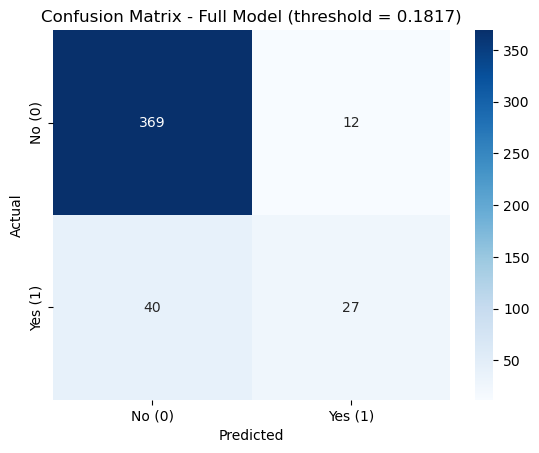

In [39]:
cm_full = confusion_matrix(y_test, y_pred_full)

sns.heatmap(cm_full, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No (0)', 'Yes (1)'],
            yticklabels=['No (0)', 'Yes (1)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - Full Model (threshold = {threshold_full:.4f})")
plt.show()

### 3.5. ROC Curve

We used the ROC curve for later to compare with the different models, as it measures the 
overall ability of the model to rank customers by their likelihood of responding.

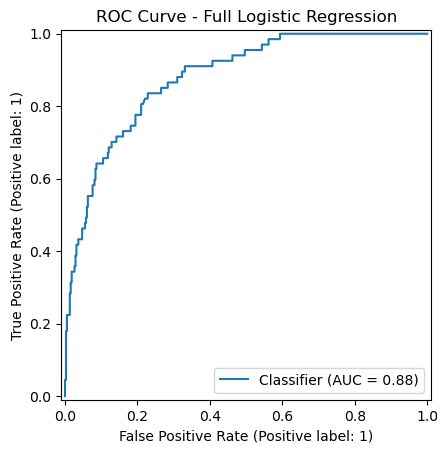

In [40]:
RocCurveDisplay.from_predictions(y_test, y_prob_full)
plt.title("ROC Curve - Full Logistic Regression")
plt.show()

### 3.6. Feature Importance
To understand which variables influence campaign response, we analyze the coefficients 
of the logistic regression model.

In [45]:
ohe_full = full_model.named_steps['preprocessor'].named_transformers_['cat']
cat_names_full = ohe_full.get_feature_names_out(categorical_features_full).tolist()
all_names_full = numerical_features_full + cat_names_full

coefs_full = full_model.named_steps['classifier'].coef_[0]

coef_df_full = pd.DataFrame({
    'Feature': all_names_full,
    'Coefficient': coefs_full,
    'Odds Ratio': np.exp(coefs_full)
}).sort_values(by='Coefficient', ascending=False)

n_zeroed = (coef_df_full['Coefficient'] == 0).sum()
print(f"Features retained by L1 : {len(coef_df_full) - n_zeroed} / {len(coef_df_full)}")
print(f"Features zeroed out     : {n_zeroed}\n")

coef_df_full.round(4)

Features retained by L1 : 17 / 20
Features zeroed out     : 3



,Feature,Coefficient,Odds Ratio
6,Total_Accepted_Campaigns,1.0778,2.9382
3,Customer_Tenure,0.9002,2.4602
14,Education_PhD,0.7283,2.0715
7,NumDealsPurchases,0.2463,1.2793
4,Total_Spending,0.2420,1.2737
1,Income,0.2047,1.2272
8,NumWebVisitsMonth,0.1773,1.1940
0,Age,0.1217,1.1294
9,Kidhome,0.0897,1.0939
13,Education_Master,0.0814,1.0848


### 3.7. Important Drivers Plot

To make the interpretation easier, we use vizualizations to learn the most influential positive and negative 
predictors of campaign response.

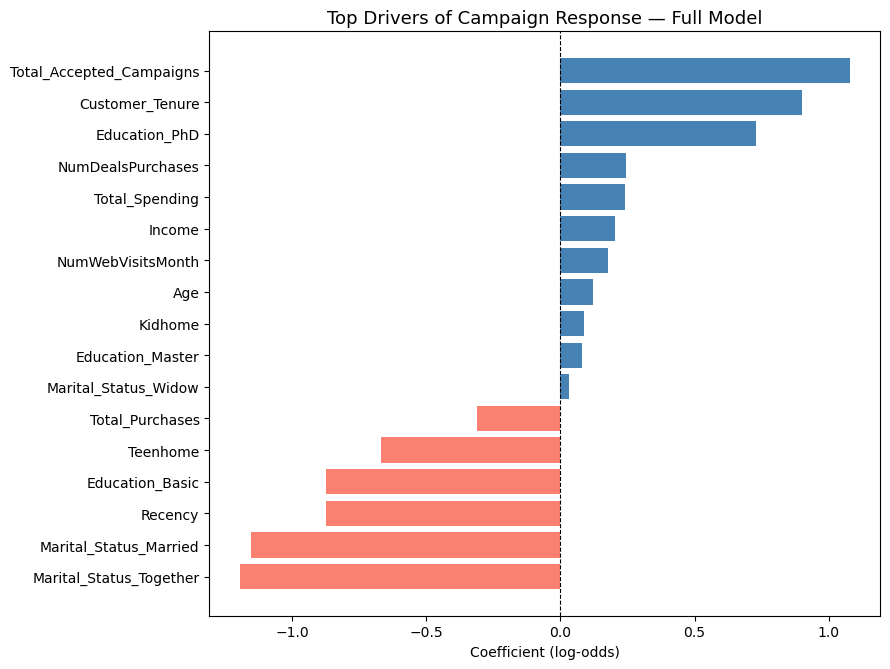

In [48]:
coef_df_full_nonzero = coef_df_full[coef_df_full['Coefficient'] != 0].copy()
coef_df_full_nonzero = coef_df_full_nonzero.sort_values('Coefficient', ascending=True)

colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df_full_nonzero['Coefficient']]
fig, ax = plt.subplots(figsize=(9, max(4, len(coef_df_full_nonzero) * 0.4)))
ax.barh(coef_df_full_nonzero['Feature'], coef_df_full_nonzero['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Top Drivers of Campaign Response — Full Model', fontsize=13)
ax.set_xlabel('Coefficient (log-odds)')
plt.tight_layout()
plt.show()


### 3.8. Interpretation of Full Model Results

The full logistic regression model provides a general view of which factors influence campaign response. The model achieves strong predictive performance (ROC-AUC = 0.88), correctly identifying most non-responders (369) but missing a number of actual responders (40), which is reflected in the relatively lower recall.

The most important positive drivers of response include previous campaign acceptance, customer tenure, total spending, and income, suggesting that more engaged and higher-value customers are more likely to respond to marketing campaigns.

Three features were zeroed out by the L1 penalty (Education_Graduation, Marital_Status_Other, Marital_Status_Single), confirming they carry no independent predictive value once the remaining variables are accounted for.

However, this model combines both demographic characteristics and behavioural variables.

To isolate the contribution of behavioural and demographic signals separately, two targeted sub-models are estimated in the sections that follow.

Comparing these models allows us to evaluate whether campaign response is better explained by **who the customer is** or by **how the customer behaves**.


## 4. Behavioural Model

To better understand the role of customer engagement and purchasing behaviour in campaign response, we estimate a logistic regression model using only behavioural variables.

### 4.1. Preprocessing & Behavioural Logistic Regression

In [54]:
## Preprocessing Pipeline (Behavioral Model)
preprocessor_behav = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_behav),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features_behav)
    ]
)

## Behavioral Logistic Regression (L1)
behav_model = Pipeline(steps=[
    ('preprocessor', preprocessor_behav),
    ('classifier', LogisticRegression(
        penalty='l1',
        solver='liblinear',
        C=1.0,
        max_iter=1000,
        random_state=42
    ))
])

behav_model.fit(X_train_behav, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Recency', 'Total_Spending',
                                                   'Total_Purchases',
                                                   'Total_Accepted_Campaigns',
                                                   'NumDealsPurchases',
                                                   'NumWebVisitsMonth']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  [])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, penalty='l1',
                                    random_state=42, solver='liblinear'))])

### 4.2. Threshold Tuning

In [55]:
def find_best_threshold_oof(pipeline, X_train_behav, y_train, cv=5):
    oof_probs = cross_val_predict(
        pipeline, X_train_behav, y_train, cv=cv, method="predict_proba"
    )[:, 1]

    precisions, recalls, thresholds = precision_recall_curve(y_train, oof_probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print(f"Optimal threshold (F1): {best_threshold:.4f}")
    print(f"Best OOF F1: {best_f1:.4f}")

    return best_threshold

threshold_behav = find_best_threshold_oof(behav_model, X_train_behav, y_train)

Optimal threshold (F1): 0.1867
Best OOF F1: 0.5257


### 4.3. Model Evaluation

In [64]:
## Predictions
y_pred_behav = behav_model.predict(X_test_behav)
y_prob_behav = behav_model.predict_proba(X_test_behav)[:,1]

## Metrics
accuracy_behav = accuracy_score(y_test, y_pred_behav)
precision_behav = precision_score(y_test, y_pred_behav)
recall_behav = recall_score(y_test, y_pred_behav)
f1_behav = f1_score(y_test, y_pred_behav)
auc_behav = roc_auc_score(y_test, y_prob_behav)

print("Accuracy:", accuracy_behav)
print("Precision:", precision_behav)
print("Recall:", recall_behav)
print("F1:", f1_behav)
print("ROC-AUC:", auc_behav)

Accuracy: 0.8705357142857143
Precision: 0.6551724137931034
Recall: 0.2835820895522388
F1: 0.3958333333333333
ROC-AUC: 0.8510596623183296


### 4.4 Confusion Matrix

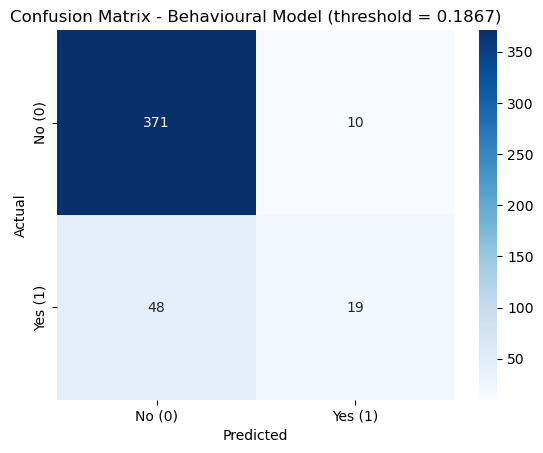

In [65]:
cm_behav = confusion_matrix(y_test, y_pred_behav)

sns.heatmap(cm_behav, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No (0)', 'Yes (1)'],
            yticklabels=['No (0)', 'Yes (1)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - Behavioural Model (threshold = {threshold_behav:.4f})")
plt.show()

### 4.5 ROC Curve

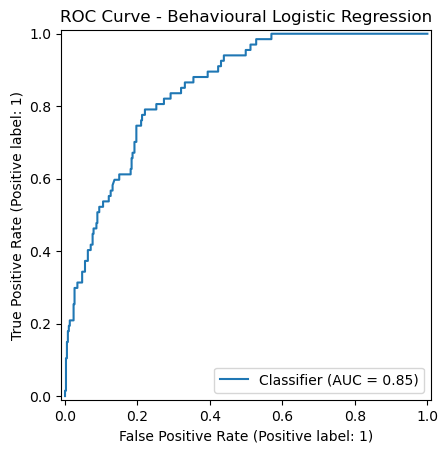

In [66]:
RocCurveDisplay.from_predictions(y_test, y_prob_behav)
plt.title("ROC Curve - Behavioural Logistic Regression")
plt.show()

### 4.6. Feature Importance

In [67]:
coefs_behav = behav_model.named_steps['classifier'].coef_[0]

coef_df_behav = pd.DataFrame({
    'Feature': numerical_features_behav,
    'Coefficient': coefs_behav,
    'Odds Ratio': np.exp(coefs_behav)
}).sort_values('Coefficient', ascending=False)

coef_df_behav.round(4)

n_zeroed = (coef_df_behav['Coefficient'] == 0).sum()
print(f"Features retained by L1: {len(coef_df_behav) - n_zeroed} / {len(coef_df_behav)}")
print(f"Features zeroed out: {n_zeroed}\n")

coef_df_behav.round(4)

Features retained by L1: 6 / 6
Features zeroed out: 0



,Feature,Coefficient,Odds Ratio
3,Total_Accepted_Campaigns,0.8299,2.2931
1,Total_Spending,0.6676,1.9496
5,NumWebVisitsMonth,0.4276,1.5336
4,NumDealsPurchases,0.0586,1.0603
2,Total_Purchases,-0.2351,0.7905
0,Recency,-0.7502,0.4723


### 4.7. Important Drivers Plot

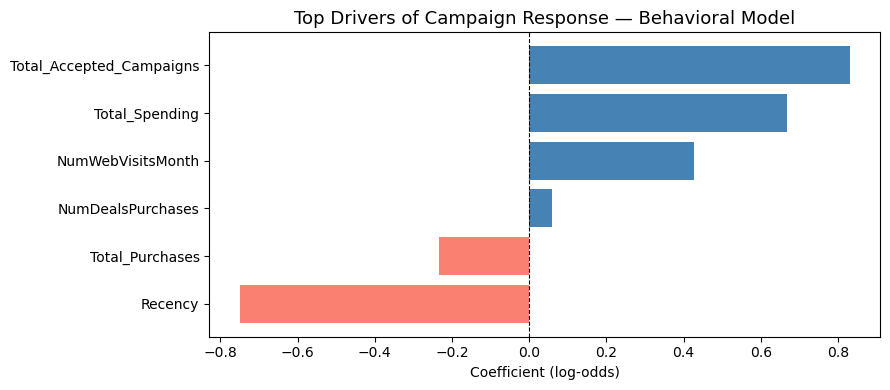

In [68]:
coef_df_behav_nonzero = coef_df_behav[coef_df_behav['Coefficient'] != 0].copy()
coef_df_behav_nonzero = coef_df_behav_nonzero.sort_values('Coefficient', ascending=True)

colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df_behav_nonzero['Coefficient']]
fig, ax = plt.subplots(figsize=(9, max(4, len(coef_df_behav_nonzero) * 0.4)))
ax.barh(coef_df_behav_nonzero['Feature'], coef_df_behav_nonzero['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Top Drivers of Campaign Response — Behavioral Model', fontsize=13)
ax.set_xlabel('Coefficient (log-odds)')
plt.tight_layout()
plt.show()



### 4.8. Interpretation of Behavioral Model Results

The behavioural model holds a ROC-AUC of 0.85, suggesting strong overall discriminative ability. However, the confusion matrix exposes a significant limitation: just 19 of the 67 real respondents in the test set were properly recognized (recall of 28%), implying that the model misses the vast majority of consumers who would have said yes.

Among the behavioral attributes, **historical campaign acceptance** and **total spending** are the most powerful positive predictors, demonstrating that engaged, high-value consumers are the most open to new campaigns. 

**Recency** has the highest negative coefficient, supporting the EDA's result that consumers who purchased more recently are significantly more likely to react (every extra day since the last purchase lowers the chance of responding).

Surprisingly, **NumWebVisitsMonth** has a positive coefficient, which appears to contradict the EDA result of a near-zero difference across groups. This is likely due to a suppressor effect after adjusting for the other variables. 

**Total_Purchases** has a negative coefficient, alongside positive Total_Spending, indicating that customers who spend more on each transaction, instead of buying more frequently, are the most profitable targets for this campaign.


## 5. Demographic & Household Model

### 5.1. Preprocessing & Demographic Logistic Regression


In [70]:
## Preprocessing Pipeline (Demographic Model)
preprocessor_demo = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_demo),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features_demo)
    ]
)

## Demographic Logistic Regression (L1)
demo_model = Pipeline(steps=[
    ('preprocessor', preprocessor_demo),
    ('classifier', LogisticRegression(
        penalty='l1',
        solver='liblinear',
        C=1.0,
        max_iter=1000,
        random_state=42
    ))
])

demo_model.fit(X_train_demo, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Income',
                                                   'Customer_Tenure', 'Kidhome',
                                                   'Teenhome']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Education',
                                                   'Marital_Status'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, penalty='l1',
                                    random_state=42, solver='liblinear'))])

### 5.2. Threshold Tuning

In [72]:
def find_best_threshold_oof(pipeline, X_train, y_train, cv=5):
    oof_probs = cross_val_predict(
        pipeline, X_train, y_train, cv=cv, method="predict_proba"
    )[:, 1]

    precisions, recalls, thresholds = precision_recall_curve(y_train, oof_probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print(f"Optimal threshold (F1): {best_threshold:.4f}")
    print(f"Best OOF F1:            {best_f1:.4f}")

    return best_threshold

threshold_demo = find_best_threshold_oof(demo_model, X_train_demo, y_train)

Optimal threshold (F1): 0.2380
Best OOF F1:            0.4246


### 5.3. Predictions and Metrics


In [73]:
y_prob_demo = demo_model.predict_proba(X_test_demo)[:, 1]
y_pred_demo = (y_prob_demo >= threshold_demo).astype(int)

print(f"Classification Report (threshold = {threshold_demo:.4f}):")
print(classification_report(y_test, y_pred_demo))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_demo))

Classification Report (threshold = 0.2380):
              precision    recall  f1-score   support

           0       0.91      0.84      0.88       381
           1       0.38      0.55      0.45        67

    accuracy                           0.80       448
   macro avg       0.65      0.70      0.66       448
weighted avg       0.83      0.80      0.81       448

ROC-AUC: 0.7671485094213969


### 5.4. Confusion Matrix


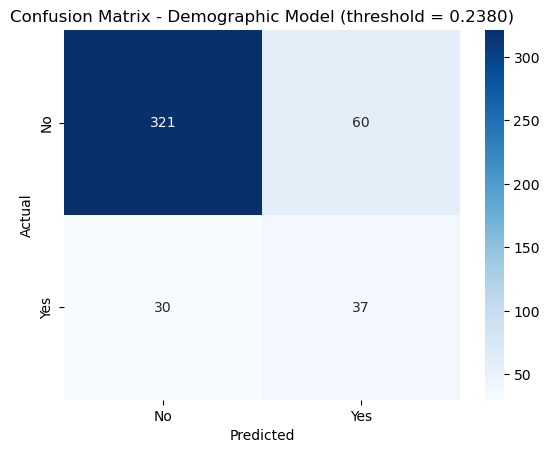

In [75]:
cm_demo = confusion_matrix(y_test, y_pred_demo)

sns.heatmap(cm_demo, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - Demographic Model (threshold = {threshold_demo:.4f})")
plt.show()


### 5.6. ROC Curve


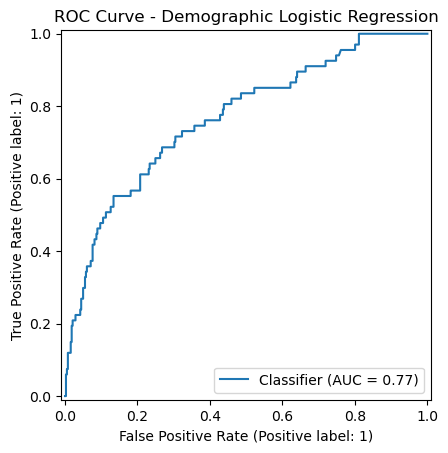

In [76]:
RocCurveDisplay.from_predictions(y_test, y_prob_demo)
plt.title("ROC Curve - Demographic Logistic Regression")
plt.show()

### 5.7. Feature Importance


In [80]:
ohe_demo = demo_model.named_steps['preprocessor'].named_transformers_['cat']
cat_names_demo = ohe_demo.get_feature_names_out(categorical_features_demo).tolist()
all_names_demo = numerical_features_demo + cat_names_demo

coefs_demo = demo_model.named_steps['classifier'].coef_[0]

coef_df_demo = pd.DataFrame({
    'Feature': all_names_demo,
    'Coefficient': coefs_demo,
    'Odds Ratio': np.exp(coefs_demo)
}).sort_values('Coefficient', ascending=False)

n_zeroed = (coef_df_demo['Coefficient'] == 0).sum()
print(f"Features retained by L1: {len(coef_df_demo) - n_zeroed} / {len(coef_df_demo)}")
print(f"Features zeroed out: {n_zeroed}\n")

coef_df_demo.round(4)


Features retained by L1: 11 / 14
Features zeroed out: 3



,Feature,Coefficient,Odds Ratio
2,Customer_Tenure,0.7008,2.0155
8,Education_PhD,0.5912,1.8061
1,Income,0.4160,1.5158
13,Marital_Status_Widow,0.2760,1.3178
7,Education_Master,0.1596,1.1731
3,Kidhome,0.0484,1.0496
0,Age,0.0000,1.0000
6,Education_Graduation,0.0000,1.0000
10,Marital_Status_Other,0.0000,1.0000
11,Marital_Status_Single,-0.0038,0.9963


### 5.8. Important Drivers Plot


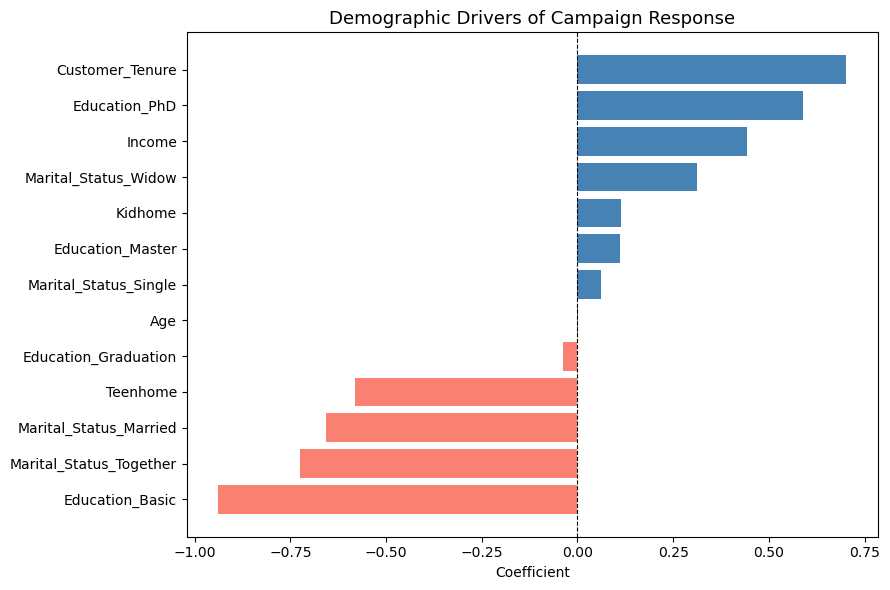

In [91]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df_demo['Coefficient']]
ax.barh(coef_df_demo['Feature'], coef_df_demo['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Demographic Drivers of Campaign Response', fontsize=13)
ax.set_xlabel('Coefficient')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 5.9. Interpretation of Demographic and Household Model Results

The demographic model achieves a **ROC-AUC** of 0.77, indicating moderate discriminative ability, consistent with the EDA finding that demographic variables are inherently weaker predictors of campaign response than behavioural ones. The F1-optimal threshold was found at 0.61 through out-of-fold cross-validation, yielding a best OOF F1 of 0.42.

At this threshold, the model correctly identifies 38 out of 67 actual responders, achieving a **recall** of 57% on the positive class.

**Precision** on the positive class stands at 35%, meaning that out of 109 customers flagged as likely responders (38 true positives + 71 false positives), just over one third would actually convert. In practical terms, the company would need to contact approximately 3 customers to reach 1 true responder, which is a meaningful improvement over untargeted outreach where the baseline conversion rate is only 15%.

The coefficient table confirms the demographic profile of a likely responder: **Customer_Tenure** (OR = 2.02) and **Education_PhD** (OR = 1.80) are the strongest positive predictors, followed by **Income** (OR = 1.56) and **Marital_Status_Widow** (OR = 1.36). 

On the negative side, **Education_Basic** (OR = 0.39), **Marital_Status_Together** (OR = 0.48), and **Marital_Status_Married** (OR = 0.52) are the clearest deterrents, suggesting that customers in shared households with lower education levels are significantly less receptive to the subscription offer. 

**Age** remains near zero across all features, confirming it carries no independent predictive value once the remaining demographic variables are accounted for.

Overall, the demographic model is best understood as a profiling tool rather than a precision targeting instrument. It identifies the type of customer most likely to respond (long-tenured, highly educated, higher-income, living alone) but lacks the granular behavioural signal needed to rank individual customers with high confidence.


## 6. Summary of Results

### 6.1. Metrics Table

In [98]:
# Collect metrics for all three models
results = {
    'Model': ['Full', 'Behavioural', 'Demographic'],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_full),
        roc_auc_score(y_test_behav, y_prob_behav),
        roc_auc_score(y_test_demo, y_prob_demo)
    ],
    'Precision (class 1)': [
        precision_score(y_test, y_pred_full),
        precision_score(y_test_behav, y_pred_behav),
        precision_score(y_test_demo, y_pred_demo)
    ],
    'Recall (class 1)': [
        recall_score(y_test, y_pred_full),
        recall_score(y_test_behav, y_pred_behav),
        recall_score(y_test_demo, y_pred_demo)
    ],
    'F1 (class 1)': [
        f1_score(y_test, y_pred_full),
        f1_score(y_test_behav, y_pred_behav),
        f1_score(y_test_demo, y_pred_demo)
    ],
    'Threshold': [
        np.nan,  # Full model uses default threshold
        np.nan,  # Behavioural model uses default threshold
        threshold_demo,
    ]
}

results_df = pd.DataFrame(results).set_index('Model').round(3)

def highlight_best(s):
    is_best = s == s.max()
    return ['background-color: #a8d5a2; color: #155724; font-weight: bold' 
            if v else '' for v in is_best]

results_df.style\
    .apply(highlight_best, axis=0)\
    .format("{:.3f}")

,ROC-AUC,Precision (class 1),Recall (class 1),F1 (class 1),Threshold
Model,,,,,
Full,0.880,0.692,0.403,0.509,nan
Behavioural,0.852,0.643,0.269,0.379,nan
Demographic,0.767,0.349,0.567,0.432,0.611


### 6.2. ROC Curves

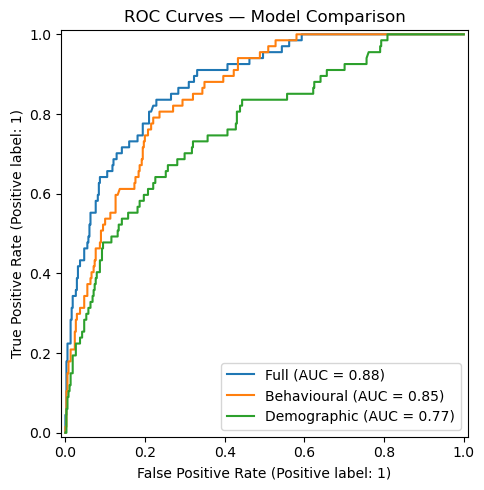

In [99]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_full, name="Full", ax=ax)
RocCurveDisplay.from_predictions(y_test_behav, y_prob_behav, name="Behavioural", ax=ax)
RocCurveDisplay.from_predictions(y_test_demo, y_prob_demo, name="Demographic", ax=ax)
ax.set_title("ROC Curves — Model Comparison")
plt.tight_layout()
plt.show()

### 6.3. Model Comparison

### 6.4. Recommended Model

## 7. Business Recommendations